# 1. Set up

In [49]:
import pandas as pd
from pathlib import Path
from scipy.stats import wilcoxon
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import json
from pathlib import Path

# 2. Loading and preprocessing data

In [73]:
# ============================================================
# SETUP: read results and create analysis datasets
# ============================================================

results_dir = Path("results")
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Result files
# ------------------------------------------------------------

metric_files = {
    "baseline_rc": "baselines_RC_metrics_full_deepeval.csv",
    "baseline_llama": "baselines_llama_metrics_full_deepeval.csv",
    "mbg_rc": "mbg_RC_metrics_full_deepeval.csv",
    "mbg_llama": "mbg_llama_metrics_full_deepeval.csv",
    "mbg_noMasking": "mbg_ablations_noMasking_metrics_full_deepeval.csv",
    "mbg_genOnly": "mbg_ablations_noGens_metrics_full_deepeval.csv",
    "mbg_noBalancing": "mbg_ablations_noBalancing_metrics_full_deepeval.csv",
}

jsonl_files = {
    "baseline_rc": "baselines_RC.jsonl",
    "baseline_llama": "baselines_llama.jsonl",
    "mbg_rc": "mbg_RC.jsonl",
    "mbg_llama": "mbg_llama.jsonl",
    "mbg_noMasking": "mbg_ablations_noMasking.jsonl",
    "mbg_genOnly": "mbg_ablations_noGens.jsonl",
    "mbg_noBalancing": "mbg_ablations_noBalancing.jsonl",
}

name_map = {
    "baseline_rc_baseline1": "Baseline1_RC",
    "baseline_rc_baseline2": "Baseline2_RC",
    "baseline_llama_baseline1": "Baseline1_Llama",
    "baseline_llama_baseline2": "Baseline2_Llama",
    "mbg_rc_mbg": "MBG_RC",
    "mbg_llama_mbg": "MBG_Llama",
    "mbg_noMasking_mbg_no_masking": "MBG_NoMasking",
    "mbg_noBalancing_mbg_no_balancing": "MBG_NoBalancing",
    "mbg_genOnly_mbg_generator_only": "MBG_GenOnly",
}

# ------------------------------------------------------------
# Load metric CSVs
# ------------------------------------------------------------

metric_dfs = []

for method, file in metric_files.items():
    df = pd.read_csv(results_dir / file)
    df["method"] = method
    metric_dfs.append(df)

metrics_df = pd.concat(metric_dfs, ignore_index=True)

metrics_df["method_full"] = (
    metrics_df["method"] + "_" + metrics_df["pipeline"]
).replace(name_map)

# ------------------------------------------------------------
# Load runtime/token data from JSONL files
# ------------------------------------------------------------

runtime_rows = []

for method, file in jsonl_files.items():
    with open(results_dir / file, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)

            token_usage = row.get("token_usage") or {}

            runtime_rows.append({
                "method": method,
                "pipeline": row.get("pipeline"),
                "batch_id": row.get("batch_id"),
                "prompt_name": row.get("prompt_name"),
                "run_index": row.get("run_index"),
                "execution_time_seconds": row.get("execution_time_seconds"),
                "n_requests": row.get("n_requests"),
                "prompt_tokens": token_usage.get("prompt_tokens"),
                "completion_tokens": token_usage.get("completion_tokens"),
                "total_tokens": token_usage.get("total_tokens"),
            })

runtime_df = pd.DataFrame(runtime_rows)

runtime_df["method_full"] = (
    runtime_df["method"] + "_" + runtime_df["pipeline"]
).replace(name_map)

# ------------------------------------------------------------
# Merge metrics with runtime/token information
# ------------------------------------------------------------

merge_keys = [
    "method_full",
    "batch_id",
    "prompt_name",
    "run_index",
]

all_results = metrics_df.merge(
    runtime_df[
        merge_keys
        + [
            "execution_time_seconds",
            "n_requests",
            "prompt_tokens",
            "completion_tokens",
            "total_tokens",
        ]
    ],
    on=merge_keys,
    how="left",
)

# ------------------------------------------------------------
# Clean duplicate request columns after merge
# ------------------------------------------------------------

all_results["n_requests"] = all_results["n_requests_y"]

# optional: drop messy duplicate columns
all_results = all_results.drop(
    columns=["n_requests_x", "n_requests_y"],
    errors="ignore"
)

# ------------------------------------------------------------
# Split prompts again after cleaning
# ------------------------------------------------------------

prompt1 = all_results[all_results["prompt_name"] == "prompt1"].copy()
prompt2 = all_results[all_results["prompt_name"] == "prompt2"].copy()

# ------------------------------------------------------------
# Batch-level dataset
# ------------------------------------------------------------

metric_cols = [
    "summarization_score",
    "alignment_score",
    "coverage_score",
    "hedge_count",
    "ec_sex",
    "ec_region",
    "ec_age_group",
    "ec_invalidity",
    "ec_idp_status",
    "ec_relative_deceased_disappeared_war",
    "ec_lonely_elderly",
    "execution_time_seconds",
    "n_requests",
    "prompt_tokens",
    "completion_tokens",
    "total_tokens",
    "runtime_generation_seconds",
    "rt_deepeval_seconds",
    "rt_ec_seconds",
    "rt_hedging_seconds",
]

batch_summary = (
    prompt1
    .groupby(["method_full", "batch_id"])[metric_cols]
    .mean()
    .reset_index()
)

ec_columns = [
    "ec_sex",
    "ec_region",
    "ec_age_group",
    "ec_invalidity",
    "ec_idp_status",
    "ec_relative_deceased_disappeared_war",
    "ec_lonely_elderly",
]

batch_summary["ec_mean"] = batch_summary[ec_columns].mean(axis=1)

# ------------------------------------------------------------
# Runtime fallback and GPT baseline token estimates
# ------------------------------------------------------------

runtime_parts = [
    "runtime_generation_seconds",
    "rt_deepeval_seconds",
    "rt_ec_seconds",
    "rt_hedging_seconds",
]

batch_summary["runtime_total_seconds"] = batch_summary["execution_time_seconds"]

missing_runtime = batch_summary["runtime_total_seconds"].isna()

batch_summary.loc[missing_runtime, "runtime_total_seconds"] = (
    batch_summary.loc[missing_runtime, runtime_parts]
    .sum(axis=1, skipna=True)
)

gpt_token_sums = {
    "Baseline1_RC": 3958333.3,
    "Baseline2_RC": 3634259.3,
}

for method, total_sum in gpt_token_sums.items():
    n_rows = (all_results["method_full"] == method).sum()
    mean_tokens = total_sum / n_rows

    batch_summary.loc[
        batch_summary["method_full"] == method,
        "total_tokens"
    ] = mean_tokens

    print(
        f"{method}: total_sum={total_sum:.1f}, "
        f"n_rows={n_rows}, mean={mean_tokens:.2f}"
    )

cost_summary = (
    batch_summary
    .groupby("method_full")[
        [
            "runtime_total_seconds",
            "n_requests",
            "prompt_tokens",
            "completion_tokens",
            "total_tokens",
        ]
    ]
    .mean()
    .rename(columns={
        "runtime_total_seconds": "Runtime (s)",
        "n_requests": "Requests",
        "prompt_tokens": "Prompt Tokens",
        "completion_tokens": "Completion Tokens",
        "total_tokens": "Total Tokens",
    })
    .round(2)
)

runtime_summary = cost_summary[["Runtime (s)", "Requests"]]
token_summary = cost_summary[["Prompt Tokens", "Completion Tokens", "Total Tokens"]]

# ------------------------------------------------------------
# Quick sanity checks
# ------------------------------------------------------------

print("\nMethods:")
print(sorted(all_results["method_full"].dropna().unique()))

print("\nPrompt1 counts:")
print(prompt1["method_full"].value_counts())

print("\nUnique batches:")
print(batch_summary.groupby("method_full")["batch_id"].nunique())

print("\nRuntime summary:")
display(runtime_summary)

print("\nToken summary:")
display(token_summary)

print("\nSetup complete.")

Baseline1_RC: total_sum=3958333.3, n_rows=216, mean=18325.62
Baseline2_RC: total_sum=3634259.3, n_rows=216, mean=16825.27

Methods:
['Baseline1_Llama', 'Baseline1_RC', 'Baseline2_Llama', 'Baseline2_RC', 'MBG_GenOnly', 'MBG_Llama', 'MBG_NoBalancing', 'MBG_NoMasking', 'MBG_RC']

Prompt1 counts:
method_full
Baseline1_RC       108
Baseline2_RC       108
Baseline1_Llama    108
Baseline2_Llama    108
MBG_RC             108
MBG_Llama          108
MBG_NoMasking      108
MBG_GenOnly        108
MBG_NoBalancing    108
Name: count, dtype: int64

Unique batches:
method_full
Baseline1_Llama    36
Baseline1_RC       36
Baseline2_Llama    36
Baseline2_RC       36
MBG_GenOnly        36
MBG_Llama          36
MBG_NoBalancing    36
MBG_NoMasking      36
MBG_RC             36
Name: batch_id, dtype: int64

Runtime summary:


,Runtime (s),Requests
method_full,,
Baseline1_Llama,53.44,1.0
Baseline1_RC,89.52,1.0
Baseline2_Llama,73.91,2.0
Baseline2_RC,75.41,2.0
MBG_GenOnly,5.19,NaN
MBG_Llama,206.65,21.0
MBG_NoBalancing,116.47,NaN
MBG_NoMasking,80.30,NaN
MBG_RC,115.48,21.0



Token summary:


,Prompt Tokens,Completion Tokens,Total Tokens
method_full,,,
Baseline1_Llama,14373.19,267.61,14640.81
Baseline1_RC,NaN,NaN,18325.62
Baseline2_Llama,29090.39,775.00,29865.39
Baseline2_RC,NaN,NaN,16825.27
MBG_GenOnly,14680.19,234.81,14915.01
MBG_Llama,37646.39,24363.96,62010.35
MBG_NoBalancing,28347.47,13907.88,42255.35
MBG_NoMasking,24165.53,9140.58,33306.11
MBG_RC,40519.98,19262.81,59782.79



Setup complete.


# 3. RQ1

### Quick checks to see if data is complete

In [51]:
(
    batch_summary
    .groupby("method_full")
    ["summarization_score"]
    .mean()
    .sort_values(ascending=False)
)

method_full
Baseline1_RC       0.677244
Baseline2_RC       0.478842
Baseline1_Llama    0.443287
MBG_GenOnly        0.345474
MBG_NoBalancing    0.342782
MBG_Llama          0.325733
MBG_NoMasking      0.323341
MBG_RC             0.320287
Baseline2_Llama    0.126358
Name: summarization_score, dtype: float64

### Summary quality table   

In [52]:
batch_summary["method_full"].unique()

<StringArray>
['Baseline1_Llama',    'Baseline1_RC', 'Baseline2_Llama',    'Baseline2_RC',
     'MBG_GenOnly',       'MBG_Llama', 'MBG_NoBalancing',   'MBG_NoMasking',
          'MBG_RC']
Length: 9, dtype: str

In [53]:
(
    batch_summary
    .groupby("method_full")
    [["summarization_score","alignment_score","coverage_score"]]
    .mean()
    .round(3)
)

,summarization_score,alignment_score,coverage_score
method_full,,,
Baseline1_Llama,0.443,0.894,0.454
Baseline1_RC,0.677,0.685,0.964
Baseline2_Llama,0.126,0.128,0.773
Baseline2_RC,0.479,0.497,0.852
MBG_GenOnly,0.345,0.466,0.433
MBG_Llama,0.326,0.465,0.444
MBG_NoBalancing,0.343,0.529,0.363
MBG_NoMasking,0.323,0.440,0.403
MBG_RC,0.320,0.434,0.507


In [54]:
metrics_to_test = [
    "summarization_score",
    "alignment_score",
    "coverage_score",
]

comparisons = [
    ("Baseline1_RC", "MBG_RC"),
    ("Baseline2_RC", "MBG_RC"),
    ("Baseline1_RC", "Baseline2_RC"),
    ("Baseline2_Llama", "MBG_Llama"),
    ("Baseline1_Llama", "MBG_Llama"),
    ("Baseline1_Llama", "Baseline2_Llama"),
]

results = []

for metric in metrics_to_test:
    for method_a, method_b in comparisons:
        a = (
            batch_summary[batch_summary["method_full"] == method_a]
            .sort_values("batch_id")
            .reset_index(drop=True)
        )

        b = (
            batch_summary[batch_summary["method_full"] == method_b]
            .sort_values("batch_id")
            .reset_index(drop=True)
        )

        assert all(a["batch_id"] == b["batch_id"]), f"Batch mismatch: {method_a} vs {method_b}"

        test = wilcoxon(a[metric], b[metric])
        diff = a[metric] - b[metric]

        results.append({
            "metric": metric,
            "comparison": f"{method_a} vs {method_b}",
            f"mean_{method_a}": a[metric].mean(),
            f"mean_{method_b}": b[metric].mean(),
            "mean_difference": diff.mean(),
            "wilcoxon_statistic": test.statistic,
            "p_value": test.pvalue,
        })

comparison_results = pd.DataFrame(results)

comparison_results

,metric,comparison,mean_Baseline1_RC,mean_MBG_RC,mean_difference,wilcoxon_statistic,p_value,mean_Baseline2_RC,mean_Baseline2_Llama,mean_MBG_Llama,mean_Baseline1_Llama
0,summarization_score,Baseline1_RC vs MBG_RC,0.677244,0.320287,0.356957,16.0,4.918547e-09,NaN,NaN,NaN,NaN
1,summarization_score,Baseline2_RC vs MBG_RC,NaN,0.320287,0.157732,NaN,NaN,0.478842,NaN,NaN,NaN
2,summarization_score,Baseline1_RC vs Baseline2_RC,0.677244,NaN,0.199445,NaN,NaN,0.478842,NaN,NaN,NaN
3,summarization_score,Baseline2_Llama vs MBG_Llama,NaN,NaN,-0.199375,57.0,2.053974e-06,NaN,0.126358,0.325733,NaN
4,summarization_score,Baseline1_Llama vs MBG_Llama,NaN,NaN,0.117554,104.5,4.904315e-03,NaN,NaN,0.325733,0.443287
5,summarization_score,Baseline1_Llama vs Baseline2_Llama,NaN,NaN,0.316929,8.0,3.288855e-07,NaN,0.126358,NaN,0.443287
6,alignment_score,Baseline1_RC vs MBG_RC,0.684819,0.433556,0.251263,87.0,3.971919e-05,NaN,NaN,NaN,NaN
7,alignment_score,Baseline2_RC vs MBG_RC,NaN,0.433556,0.061084,NaN,NaN,0.497224,NaN,NaN,NaN
8,alignment_score,Baseline1_RC vs Baseline2_RC,0.684819,NaN,0.189084,NaN,NaN,0.497224,NaN,NaN,NaN
9,alignment_score,Baseline2_Llama vs MBG_Llama,NaN,NaN,-0.337424,20.0,1.079752e-08,NaN,0.127851,0.465274,NaN


### significance testing

In [55]:
batch_summary["ec_mean"] = (
    batch_summary[ec_columns]
    .mean(axis=1)
)


Baseline1_RC vs MBG_RC (Summarization)
N paired batches = 36
Mean difference   = 0.3570
Median difference = 0.3843
Min difference    = -0.1388
Max difference    = 0.8016
Skewness          = -0.3142


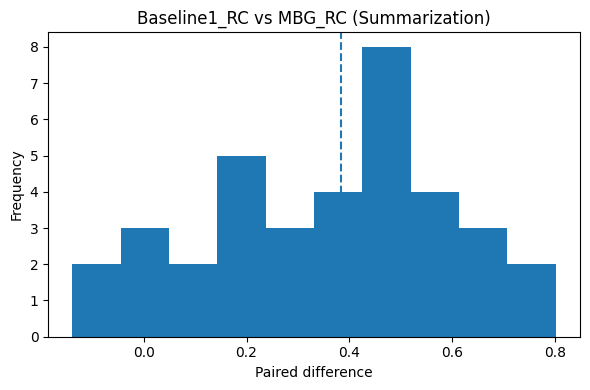


Baseline1_Llama vs MBG_Llama (Summarization)
N paired batches = 36
Mean difference   = 0.1176
Median difference = 0.1277
Min difference    = -0.2500
Max difference    = 0.5000
Skewness          = -0.0007


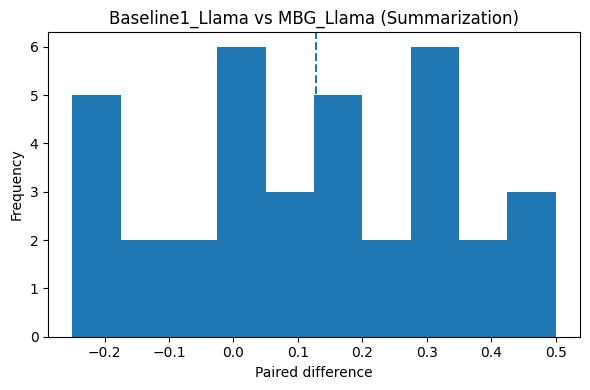


Baseline1_RC vs MBG_RC (EC)
N paired batches = 36
Mean difference   = 0.0064
Median difference = 0.0058
Min difference    = 0.0021
Max difference    = 0.0126
Skewness          = 0.6658


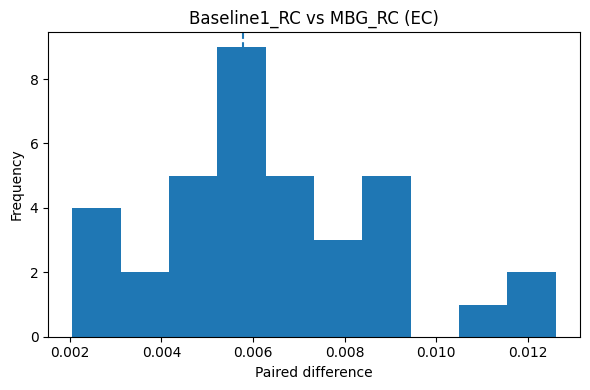


Baseline1_Llama vs MBG_Llama (EC)
N paired batches = 36
Mean difference   = 0.0074
Median difference = 0.0075
Min difference    = -0.0063
Max difference    = 0.0195
Skewness          = 0.0952


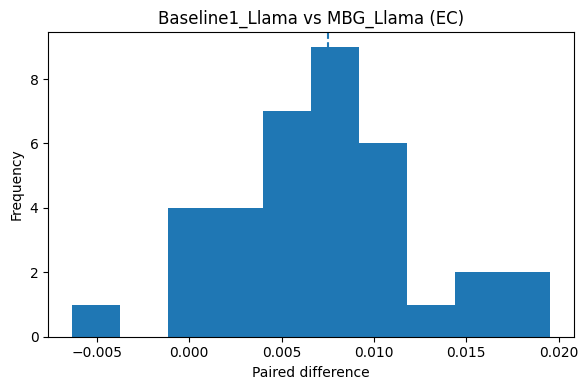

In [56]:
# ============================================================
# Wilcoxon assumption check: paired difference distributions
# ============================================================

comparisons = [
    {
        "title": "Baseline1_RC vs MBG_RC (Summarization)",
        "method_a": "Baseline1_RC",
        "method_b": "MBG_RC",
        "metric": "summarization_score",
    },
    {
        "title": "Baseline1_Llama vs MBG_Llama (Summarization)",
        "method_a": "Baseline1_Llama",
        "method_b": "MBG_Llama",
        "metric": "summarization_score",
    },
    {
        "title": "Baseline1_RC vs MBG_RC (EC)",
        "method_a": "Baseline1_RC",
        "method_b": "MBG_RC",
        "metric": "ec_mean",
    },
    {
        "title": "Baseline1_Llama vs MBG_Llama (EC)",
        "method_a": "Baseline1_Llama",
        "method_b": "MBG_Llama",
        "metric": "ec_mean",
    },
]

for comp in comparisons:
    method_a = comp["method_a"]
    method_b = comp["method_b"]
    metric = comp["metric"]

    a = (
        batch_summary[batch_summary["method_full"] == method_a]
        [["batch_id", metric]]
        .rename(columns={metric: f"{method_a}_{metric}"})
    )

    b = (
        batch_summary[batch_summary["method_full"] == method_b]
        [["batch_id", metric]]
        .rename(columns={metric: f"{method_b}_{metric}"})
    )

    paired = pd.merge(a, b, on="batch_id", how="inner")

    paired["difference"] = (
        paired[f"{method_a}_{metric}"] -
        paired[f"{method_b}_{metric}"]
    )

    diff = paired["difference"].dropna()

    print("\n" + "=" * 80)
    print(comp["title"])
    print(f"N paired batches = {len(diff)}")
    print(f"Mean difference   = {diff.mean():.4f}")
    print(f"Median difference = {diff.median():.4f}")
    print(f"Min difference    = {diff.min():.4f}")
    print(f"Max difference    = {diff.max():.4f}")
    print(f"Skewness          = {diff.skew():.4f}")

    plt.figure(figsize=(6, 4))
    plt.hist(diff, bins=10)
    plt.axvline(diff.median(), linestyle="--")
    plt.title(comp["title"])
    plt.xlabel("Paired difference")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [57]:

# --------------------------------------------------
# Wilcoxon Signed-Rank Tests (RQ1)
# --------------------------------------------------

metrics_to_test = [
    "summarization_score",
    "alignment_score",
    "coverage_score",
    "ec_mean",
    "hedge_count",
]

comparisons = [
    ("Baseline1_RC", "MBG_RC"),
    ("Baseline2_RC", "MBG_RC"),
    ("Baseline1_RC", "Baseline2_RC"),

    ("Baseline1_Llama", "MBG_Llama"),
    ("Baseline2_Llama", "MBG_Llama"),
    ("Baseline1_Llama", "Baseline2_Llama"),
]

results = []

for metric in metrics_to_test:
    for method_a, method_b in comparisons:

        # Keep only methods containing the metric
        a = (
            batch_summary[batch_summary["method_full"] == method_a]
            .sort_values("batch_id")
            .reset_index(drop=True)
        )

        b = (
            batch_summary[batch_summary["method_full"] == method_b]
            .sort_values("batch_id")
            .reset_index(drop=True)
        )

        # Skip comparisons if metric is unavailable
        if metric not in a.columns or metric not in b.columns:
            continue

        # Remove missing values
        paired = pd.concat(
            [a[["batch_id", metric]], b[[metric]]],
            axis=1
        ).dropna()

        if len(paired) == 0:
            continue

        x = paired.iloc[:, 1]
        y = paired.iloc[:, 2]

        # Wilcoxon test
        test = wilcoxon(x, y)

        # Mean difference
        diff = x - y
        n = len(diff)

        # -------- Effect size r --------
        #
        # Approximate z from the Wilcoxon statistic
        #
        expected_w = n * (n + 1) / 4
        sd_w = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)

        z = (test.statistic - expected_w) / sd_w
        r = abs(z) / np.sqrt(n)

        results.append({
            "comparison": f"{method_a} vs {method_b}",
            "metric": metric,
            "n_pairs": n,
            f"{method_a}_mean": x.mean(),
            f"{method_b}_mean": y.mean(),
            "mean_difference": diff.mean(),
            "wilcoxon_statistic": test.statistic,
            "p_value": test.pvalue,
            "effect_size_r": r,
        })

comparison_results = (
    pd.DataFrame(results)
    .sort_values(["comparison", "metric"])
    .reset_index(drop=True)
)

comparison_results

,comparison,metric,n_pairs,Baseline1_RC_mean,MBG_RC_mean,mean_difference,wilcoxon_statistic,p_value,effect_size_r,Baseline2_RC_mean,Baseline1_Llama_mean,MBG_Llama_mean,Baseline2_Llama_mean
0,Baseline1_Llama vs Baseline2_Llama,alignment_score,36,NaN,NaN,0.766292,0.0,2.910383e-11,0.871937,NaN,0.894143,NaN,0.127851
1,Baseline1_Llama vs Baseline2_Llama,coverage_score,36,NaN,NaN,-0.319444,3.0,5.802771e-07,0.864082,NaN,0.453704,NaN,0.773148
2,Baseline1_Llama vs Baseline2_Llama,ec_mean,36,NaN,NaN,0.002428,120.0,5.099171e-04,0.557725,NaN,0.011542,NaN,0.009113
3,Baseline1_Llama vs Baseline2_Llama,hedge_count,36,NaN,NaN,-3.250000,2.5,1.781008e-07,0.865391,NaN,0.277778,NaN,3.527778
4,Baseline1_Llama vs Baseline2_Llama,summarization_score,36,NaN,NaN,0.316929,8.0,3.288855e-07,0.850989,NaN,0.443287,NaN,0.126358
5,Baseline1_Llama vs MBG_Llama,alignment_score,36,NaN,NaN,0.428868,11.0,4.212017e-07,0.843134,NaN,0.894143,0.465274,NaN
6,Baseline1_Llama vs MBG_Llama,coverage_score,36,NaN,NaN,0.009259,184.5,9.132810e-01,0.388837,NaN,0.453704,0.444444,NaN
7,Baseline1_Llama vs MBG_Llama,ec_mean,36,NaN,NaN,0.007354,16.0,4.918547e-09,0.830042,NaN,0.011542,0.004187,NaN
8,Baseline1_Llama vs MBG_Llama,hedge_count,36,NaN,NaN,0.250000,4.5,2.092134e-02,0.860154,NaN,0.277778,0.027778,NaN
9,Baseline1_Llama vs MBG_Llama,summarization_score,36,NaN,NaN,0.117554,104.5,4.904315e-03,0.598311,NaN,0.443287,0.325733,NaN


### Figures

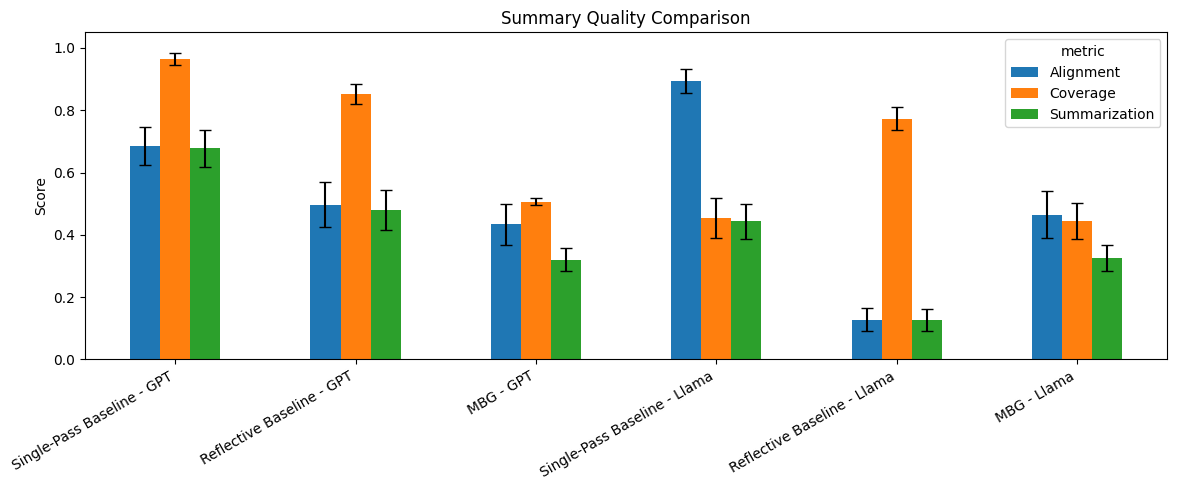

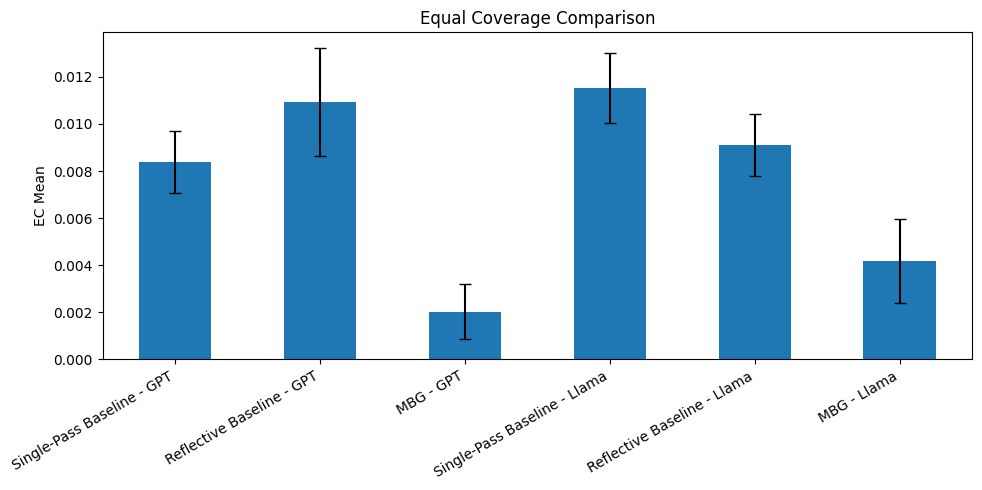

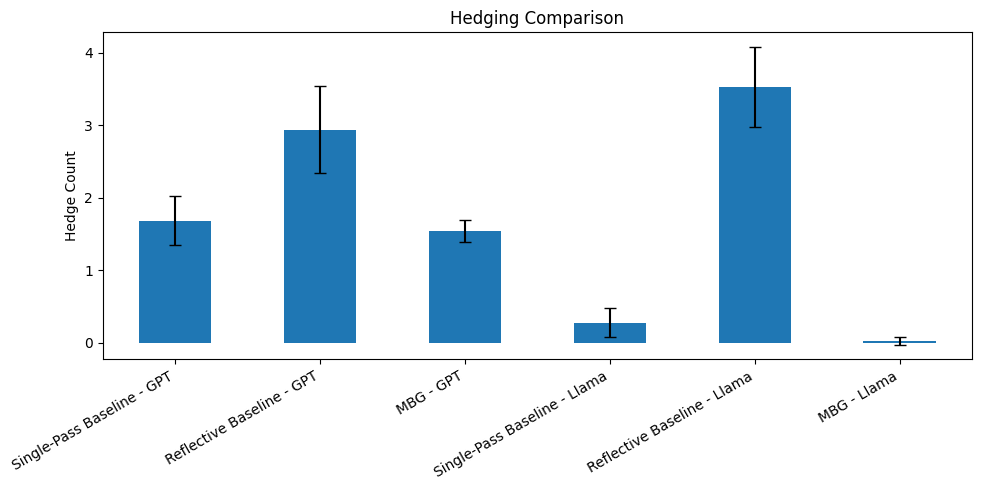

In [78]:
# ============================================================
# RQ1 Figures with 95% CI error bars
# ============================================================

fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

rq1_methods = [
    "Baseline1_RC",
    "Baseline2_RC",
    "MBG_RC",
    "Baseline1_Llama",
    "Baseline2_Llama",
    "MBG_Llama",
]

method_labels = {
    "Baseline1_RC": "Single-Pass Baseline - GPT",
    "Baseline2_RC": "Reflective Baseline - GPT",
    "MBG_RC": "MBG - GPT",
    "Baseline1_Llama": "Single-Pass Baseline - Llama",
    "Baseline2_Llama": "Reflective Baseline - Llama",
    "MBG_Llama": "MBG - Llama",
}

# ------------------------------------------------------------
# Helper: means and 95% confidence intervals
# ------------------------------------------------------------

def mean_ci_table(df, methods, metrics):
    """
    Compute mean and 95% confidence interval for each method and metric.
    CI is calculated as 1.96 * standard error.
    """
    rows = []

    for method in methods:
        subset = df[df["method_full"] == method]

        for metric in metrics:
            values = subset[metric].dropna()
            n = len(values)

            mean = values.mean()
            std = values.std(ddof=1)
            se = std / np.sqrt(n)
            ci95 = 1.96 * se

            rows.append({
                "method_full": method,
                "metric": metric,
                "mean": mean,
                "ci95": ci95,
                "n": n,
            })

    return pd.DataFrame(rows)


summary_means = summary_means[
    ["Summarization", "Alignment", "Coverage"]
]

summary_errors = summary_errors[
    ["Summarization", "Alignment", "Coverage"]
]

# ============================================================
# Figure 1: Summary quality
# ============================================================

summary_metrics = {
    "summarization_score": "Summarization",
    "alignment_score": "Alignment",
    "coverage_score": "Coverage",
}

summary_ci = mean_ci_table(
    batch_summary,
    rq1_methods,
    list(summary_metrics.keys())
)

summary_means = (
    summary_ci
    .pivot(index="method_full", columns="metric", values="mean")
    .loc[rq1_methods]
    .rename(index=method_labels, columns=summary_metrics)
)

summary_errors = (
    summary_ci
    .pivot(index="method_full", columns="metric", values="ci95")
    .loc[rq1_methods]
    .rename(index=method_labels, columns=summary_metrics)
)

ax = summary_means.plot(
    kind="bar",
    yerr=summary_errors,
    capsize=4,
    figsize=(12, 5),
)

ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_title("Summary Quality Comparison")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    fig_dir / "rq1_summary_quality.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 2: Equal Coverage
# ============================================================

ec_ci = mean_ci_table(
    batch_summary,
    rq1_methods,
    ["ec_mean"]
)

ec_means = (
    ec_ci
    .pivot(index="method_full", columns="metric", values="mean")
    .loc[rq1_methods]
    .rename(index=method_labels, columns={"ec_mean": "EC Mean"})
)

ec_errors = (
    ec_ci
    .pivot(index="method_full", columns="metric", values="ci95")
    .loc[rq1_methods]
    .rename(index=method_labels, columns={"ec_mean": "EC Mean"})
)

ax = ec_means.plot(
    y="EC Mean",
    kind="bar",
    yerr=ec_errors["EC Mean"],
    capsize=4,
    legend=False,
    figsize=(10, 5),
)

ax.set_ylabel("EC Mean")
ax.set_xlabel("")
ax.set_title("Equal Coverage Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    fig_dir / "rq1_ec_mean.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 3: Hedge Count
# ============================================================

hedge_ci = mean_ci_table(
    batch_summary,
    rq1_methods,
    ["hedge_count"]
)

hedge_means = (
    hedge_ci
    .pivot(index="method_full", columns="metric", values="mean")
    .loc[rq1_methods]
    .rename(index=method_labels, columns={"hedge_count": "Hedge Count"})
)

hedge_errors = (
    hedge_ci
    .pivot(index="method_full", columns="metric", values="ci95")
    .loc[rq1_methods]
    .rename(index=method_labels, columns={"hedge_count": "Hedge Count"})
)

ax = hedge_means.plot(
    y="Hedge Count",
    kind="bar",
    yerr=hedge_errors["Hedge Count"],
    capsize=4,
    legend=False,
    figsize=(10, 5),
)

ax.set_ylabel("Hedge Count")
ax.set_xlabel("")
ax.set_title("Hedging Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    fig_dir / "rq1_hedge_count.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 4. RQ2 Ablations

In [59]:
# ============================================================
# RQ2 - Ablation Analysis
# ============================================================
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Method labels
# ------------------------------------------------------------

rq2_methods = [
    "MBG_RC",
    "MBG_NoMasking",
    "MBG_NoBalancing",
    "MBG_GenOnly",   
]

method_labels = {
    "MBG_RC": "MBG - RC",
    "MBG_NoMasking": "MBG - No Masking",
    "MBG_NoBalancing": "MBG - No Balancing",
    "MBG_GenOnly": "MBG - Generator Only",
}

# ------------------------------------------------------------
# RQ2 descriptive summary table
# ------------------------------------------------------------

rq2_summary = (
    batch_summary[batch_summary["method_full"].isin(rq2_methods)]
    .groupby("method_full")[
        [
            "summarization_score",
            "alignment_score",
            "coverage_score",
            "ec_mean",
            "hedge_count",
        ]
    ]
    .mean()
    .loc[rq2_methods]
    .rename(index=method_labels)
    .rename(columns={
        "summarization_score": "Summarization",
        "alignment_score": "Alignment",
        "coverage_score": "Coverage",
        "ec_mean": "EC Mean",
        "hedge_count": "Hedge Count",
    })
    .round(3)
)

rq2_summary

,Summarization,Alignment,Coverage,EC Mean,Hedge Count
method_full,,,,,
MBG - RC,0.320,0.434,0.507,0.002,1.537
MBG - No Masking,0.323,0.440,0.403,0.003,0.083
MBG - No Balancing,0.343,0.529,0.363,0.006,0.028
MBG - Generator Only,0.345,0.466,0.433,0.005,0.083


In [60]:
# ============================================================
# RQ2 - Wilcoxon tests with effect sizes
# ============================================================

def wilcoxon_with_effect_size(x, y):
    """
    Runs Wilcoxon signed-rank test and returns W, p, and effect size r.

    Effect size r is approximated as:
        r = |z| / sqrt(n)

    where z is computed from the normal approximation of W.
    """
    diff = x - y
    diff = diff.dropna()

    # Remove zero differences for Wilcoxon effect-size approximation
    diff_nonzero = diff[diff != 0]
    n = len(diff_nonzero)

    if n == 0:
        return np.nan, np.nan, np.nan, 0

    test = wilcoxon(x, y)

    expected_w = n * (n + 1) / 4
    sd_w = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)

    z = (test.statistic - expected_w) / sd_w
    r = abs(z) / np.sqrt(n)

    return test.statistic, test.pvalue, r, len(diff)


rq2_comparisons = [
    ("MBG_RC", "MBG_NoMasking"),
    ("MBG_RC", "MBG_NoBalancing"),
    ("MBG_RC", "MBG_GenOnly"),
]

rq2_test_metrics = [
    "summarization_score",
    "ec_mean",
]

rq2_results = []

for metric in rq2_test_metrics:
    for method_a, method_b in rq2_comparisons:

        a = (
            batch_summary[batch_summary["method_full"] == method_a]
            .sort_values("batch_id")
            .reset_index(drop=True)
        )

        b = (
            batch_summary[batch_summary["method_full"] == method_b]
            .sort_values("batch_id")
            .reset_index(drop=True)
        )

        assert all(a["batch_id"] == b["batch_id"]), (
            f"Batch mismatch: {method_a} vs {method_b}"
        )

        x = a[metric]
        y = b[metric]
        diff = x - y

        w_stat, p_value, effect_r, n_pairs = wilcoxon_with_effect_size(x, y)

        rq2_results.append({
            "comparison": f"{method_labels[method_a]} vs {method_labels[method_b]}",
            "metric": metric,
            "n_pairs": n_pairs,
            "mean_a": x.mean(),
            "mean_b": y.mean(),
            "mean_difference": diff.mean(),
            "wilcoxon_statistic": w_stat,
            "p_value": p_value,
            "effect_size_r": effect_r,
        })

rq2_wilcoxon = pd.DataFrame(rq2_results)

rq2_wilcoxon

,comparison,metric,n_pairs,mean_a,mean_b,mean_difference,wilcoxon_statistic,p_value,effect_size_r
0,MBG - RC vs MBG - No Masking,summarization_score,36,0.320287,0.323341,-0.003055,313.0,0.753353,0.052369
1,MBG - RC vs MBG - No Balancing,summarization_score,36,0.320287,0.342782,-0.022495,293.0,0.529721,0.104737
2,MBG - RC vs MBG - Generator Only,summarization_score,36,0.320287,0.345474,-0.025188,221.0,0.287720,0.185068
3,MBG - RC vs MBG - No Masking,ec_mean,36,0.002025,0.003217,-0.001192,108.0,0.086462,0.336214
4,MBG - RC vs MBG - No Balancing,ec_mean,36,0.002025,0.006165,-0.004140,20.0,0.000019,0.793027
5,MBG - RC vs MBG - Generator Only,ec_mean,36,0.002025,0.005343,-0.003319,39.0,0.000891,0.664601


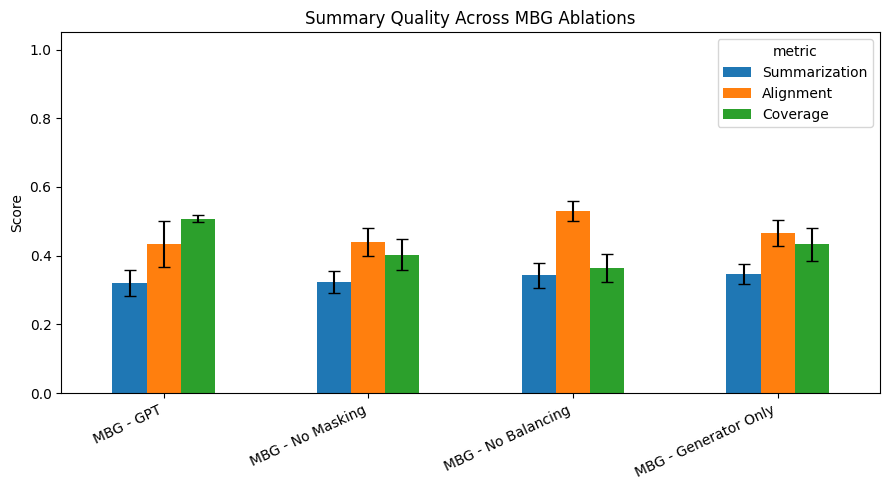

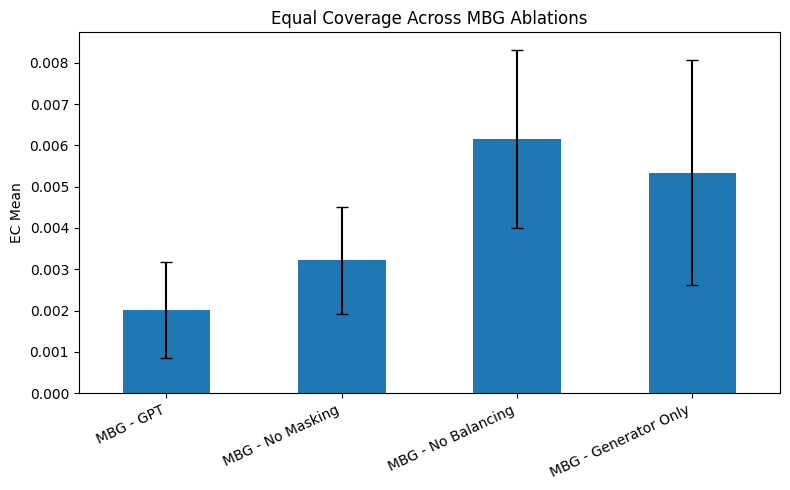

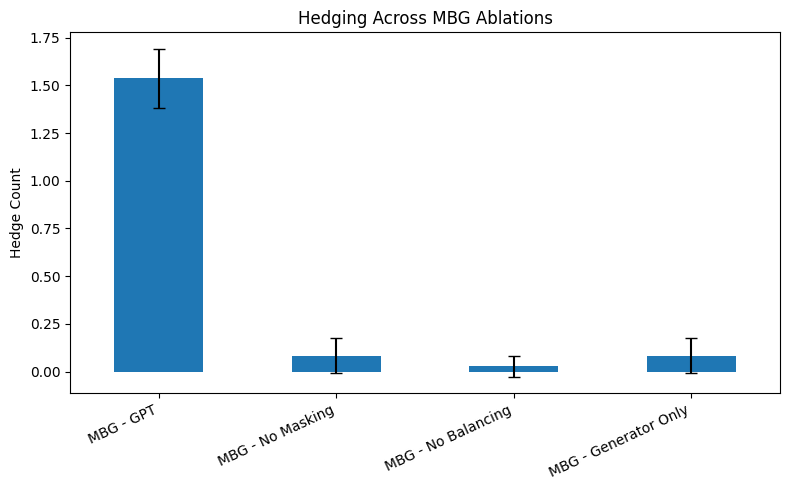

In [79]:
# ============================================================
# RQ2 Figures with 95% CI error bars
# ============================================================

fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

rq2_methods = [
    "MBG_RC",
    "MBG_NoMasking",
    "MBG_NoBalancing",
    "MBG_GenOnly",
]

rq2_labels = {
    "MBG_RC": "MBG - GPT",
    "MBG_NoMasking": "MBG - No Masking",
    "MBG_NoBalancing": "MBG - No Balancing",
    "MBG_GenOnly": "MBG - Generator Only",
}

def mean_ci_table(df, methods, metrics):
    rows = []

    for method in methods:
        subset = df[df["method_full"] == method]

        for metric in metrics:
            values = subset[metric].dropna()
            n = len(values)

            mean = values.mean()
            std = values.std(ddof=1)
            se = std / np.sqrt(n)
            ci95 = 1.96 * se

            rows.append({
                "method_full": method,
                "metric": metric,
                "mean": mean,
                "ci95": ci95,
                "n": n,
            })

    return pd.DataFrame(rows)


# ============================================================
# Figure 1: RQ2 Summary Quality
# ============================================================

summary_metrics = {
    "summarization_score": "Summarization",
    "alignment_score": "Alignment",
    "coverage_score": "Coverage",
}

rq2_summary_ci = mean_ci_table(
    batch_summary,
    rq2_methods,
    list(summary_metrics.keys())
)

rq2_summary_means = (
    rq2_summary_ci
    .pivot(index="method_full", columns="metric", values="mean")
    .loc[rq2_methods]
    .rename(index=rq2_labels, columns=summary_metrics)
)

rq2_summary_errors = (
    rq2_summary_ci
    .pivot(index="method_full", columns="metric", values="ci95")
    .loc[rq2_methods]
    .rename(index=rq2_labels, columns=summary_metrics)
)

rq2_summary_means = rq2_summary_means[
    ["Summarization", "Alignment", "Coverage"]
]

rq2_summary_errors = rq2_summary_errors[
    ["Summarization", "Alignment", "Coverage"]
]

ax = rq2_summary_means.plot(
    kind="bar",
    yerr=rq2_summary_errors,
    capsize=4,
    figsize=(9, 5),
)

ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_title("Summary Quality Across MBG Ablations")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    fig_dir / "rq2_summary_quality_ablation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 2: RQ2 Equal Coverage
# ============================================================

rq2_ec_ci = mean_ci_table(
    batch_summary,
    rq2_methods,
    ["ec_mean"]
)

rq2_ec_means = (
    rq2_ec_ci
    .pivot(index="method_full", columns="metric", values="mean")
    .loc[rq2_methods]
    .rename(index=rq2_labels, columns={"ec_mean": "EC Mean"})
)

rq2_ec_errors = (
    rq2_ec_ci
    .pivot(index="method_full", columns="metric", values="ci95")
    .loc[rq2_methods]
    .rename(index=rq2_labels, columns={"ec_mean": "EC Mean"})
)

ax = rq2_ec_means.plot(
    y="EC Mean",
    kind="bar",
    yerr=rq2_ec_errors["EC Mean"],
    capsize=4,
    legend=False,
    figsize=(8, 5),
)

ax.set_ylabel("EC Mean")
ax.set_xlabel("")
ax.set_title("Equal Coverage Across MBG Ablations")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    fig_dir / "rq2_ec_ablation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 3: RQ2 Hedge Count
# ============================================================

rq2_hedge_ci = mean_ci_table(
    batch_summary,
    rq2_methods,
    ["hedge_count"]
)

rq2_hedge_means = (
    rq2_hedge_ci
    .pivot(index="method_full", columns="metric", values="mean")
    .loc[rq2_methods]
    .rename(index=rq2_labels, columns={"hedge_count": "Hedge Count"})
)

rq2_hedge_errors = (
    rq2_hedge_ci
    .pivot(index="method_full", columns="metric", values="ci95")
    .loc[rq2_methods]
    .rename(index=rq2_labels, columns={"hedge_count": "Hedge Count"})
)

ax = rq2_hedge_means.plot(
    y="Hedge Count",
    kind="bar",
    yerr=rq2_hedge_errors["Hedge Count"],
    capsize=4,
    legend=False,
    figsize=(8, 5),
)

ax.set_ylabel("Hedge Count")
ax.set_xlabel("")
ax.set_title("Hedging Across MBG Ablations")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    fig_dir / "rq2_hedge_ablation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 5. RQ3 - Costs

In [74]:
# ------------------------------------------------------------
# RQ3 table: baseline and MBG cost comparison
# ------------------------------------------------------------

rq3_main_order = [
    "Baseline1_RC",
    "Baseline2_RC",
    "MBG_RC",
    "Baseline1_Llama",
    "Baseline2_Llama",
    "MBG_Llama",
]

rq3_cost_comparison = (
    cost_summary
    .loc[rq3_main_order, ["Runtime (s)", "Requests", "Total Tokens"]]
    .rename(index=method_labels)
)

display(rq3_cost_comparison)

,Runtime (s),Requests,Total Tokens
method_full,,,
Single-Pass Baseline - GPT,89.52,1.0,18325.62
Reflective Baseline - GPT,75.41,2.0,16825.27
MBG - GPT,115.48,21.0,59782.79
Single-Pass Baseline - Llama,53.44,1.0,14640.81
Reflective Baseline - Llama,73.91,2.0,29865.39
MBG - Llama,206.65,21.0,62010.35


In [75]:
# ------------------------------------------------------------
# RQ3 table: component-level token costs
# ------------------------------------------------------------

rq3_component_order = [
    "MBG_RC",
    "MBG_NoMasking",
    "MBG_NoBalancing",
    "MBG_GenOnly",
]

rq3_component_costs = (
    cost_summary
    .loc[rq3_component_order, ["Total Tokens"]]
    .rename(index=method_labels)
)

display(rq3_component_costs)

,Total Tokens
method_full,
MBG - GPT,59782.79
MBG - No Masking,33306.11
MBG - No Balancing,42255.35
MBG - Generator Only,14915.01


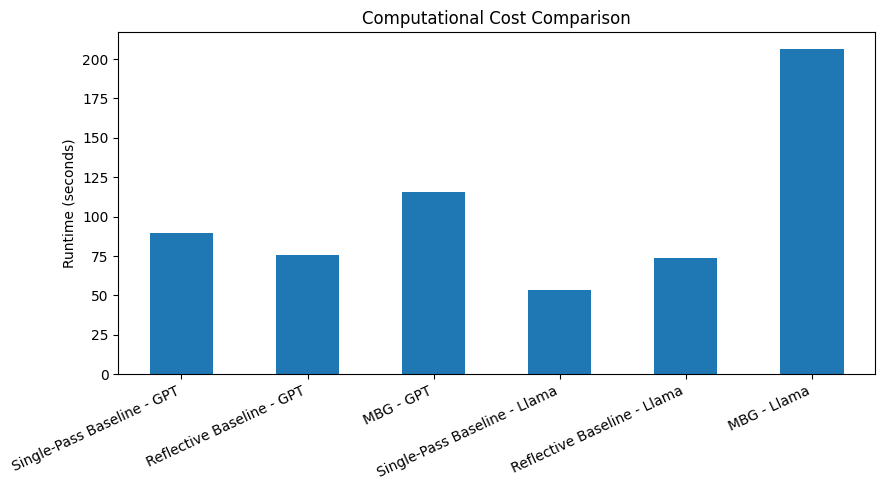

In [76]:
# ------------------------------------------------------------
# RQ3 figure: runtime comparison
# ------------------------------------------------------------

runtime_plot = rq3_cost_comparison[["Runtime (s)"]]

ax = runtime_plot.plot(
    y="Runtime (s)",
    kind="bar",
    legend=False,
    figsize=(9, 5),
)

ax.set_ylabel("Runtime (seconds)")
ax.set_xlabel("")
ax.set_title("Computational Cost Comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(fig_dir / "rq3_runtime_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# poster figures

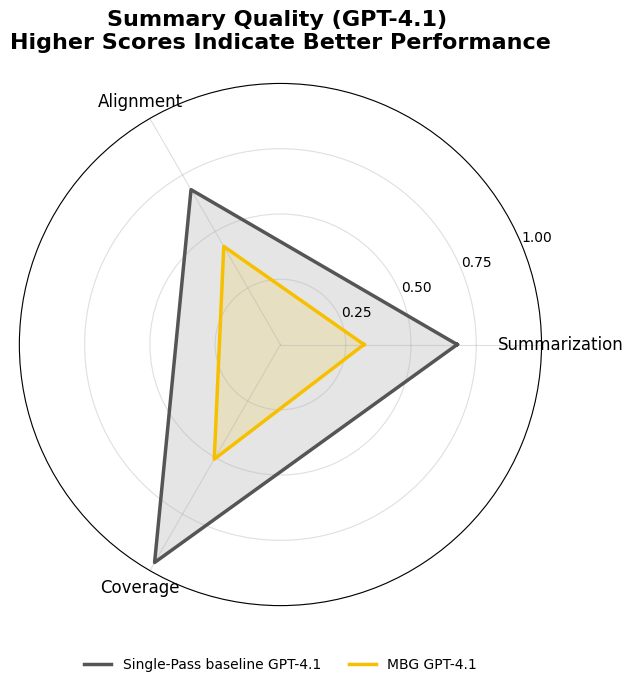

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------

labels = ["Summarization", "Alignment", "Coverage"]

baseline_rc = [0.677, 0.685, 0.964]
mbg_rc      = [0.320, 0.434, 0.507]

baseline_llama = [0.443, 0.894, 0.454]
mbg_llama      = [0.326, 0.465, 0.444]

# -----------------------------
# Colors
# -----------------------------

BASELINE = "#555555"
MBG = "#F6C000"

# -----------------------------
# Radar function
# -----------------------------

def radar_chart(labels, series, title):

    n = len(labels)

    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    for values, label, color in series:

        values = values + values[:1]

        ax.plot(
            angles,
            values,
            linewidth=2.5,
            color=color,
            label=label
        )

        ax.fill(
            angles,
            values,
            color=color,
            alpha=0.15
        )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12)

    ax.set_ylim(0,1)
    ax.set_yticks([0.25,0.50,0.75,1.00])
    ax.grid(alpha=0.4)

    ax.set_title(
        title,
        fontsize=16,
        pad=25,
        weight="bold"
    )

    ax.legend(
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

    plt.tight_layout()
    plt.show()

# -----------------------------
# Plot
# -----------------------------

radar_chart(
    labels,
    [
        (baseline_rc, "Single-Pass baseline GPT-4.1", BASELINE),
        (mbg_rc, "MBG GPT-4.1", MBG),
    ],
    "Summary Quality (GPT-4.1) \nHigher Scores Indicate Better Performance"
)

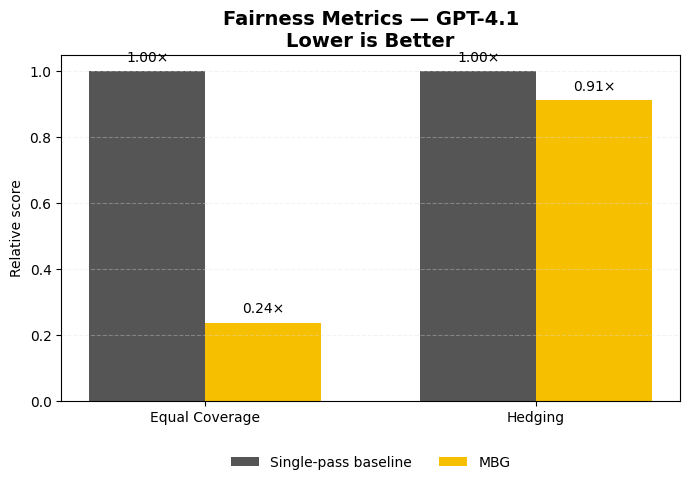

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Poster color palette
# -----------------------------
BASELINE = "#555555"  # dark gray
MBG = "#F6C000"        # UU-style yellow/gold
GRID = "#DDDDDD"

# ============================================================
# 1. FAIRNESS CHART — GPT only
# Lower is better
# ============================================================

metrics = ["Equal Coverage", "Hedging"]

baseline_gpt = [0.0084, 1.685]
mbg_gpt = [0.0020, 1.537]

# Normalize within each metric so both can be shown together
# Lower original score = better, so lower bar still means better
baseline_norm = [1.0, 1.0]
mbg_norm = [
    mbg_gpt[0] / baseline_gpt[0],
    mbg_gpt[1] / baseline_gpt[1]
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x - width/2, baseline_norm, width, label="Single-pass baseline", color=BASELINE)
ax.bar(x + width/2, mbg_norm, width, label="MBG", color=MBG)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Relative score")
ax.set_title("Fairness Metrics — GPT-4.1\nLower is Better", fontsize=14, weight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=GRID)
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

for i, value in enumerate(baseline_norm):
    ax.text(i - width/2, value + 0.03, "1.00×", ha="center", fontsize=10)

for i, value in enumerate(mbg_norm):
    ax.text(i + width/2, value + 0.03, f"{value:.2f}×", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("fairness_gpt.svg", bbox_inches="tight")
plt.savefig("fairness_gpt.png", dpi=300, bbox_inches="tight")
plt.show()

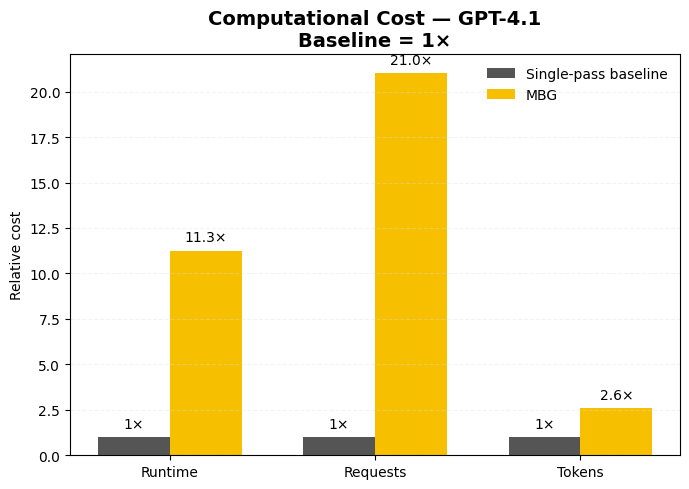

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Poster color palette
# -----------------------------
BASELINE = "#555555"
MBG = "#F6C000"
GRID = "#DDDDDD"

# ============================================================
# 2. COST CHART — GPT only
# Baseline = 1x
# Higher is more expensive
# ============================================================

metrics = ["Runtime", "Requests", "Tokens"]

baseline_gpt = [10.32, 1, 23148]
mbg_gpt = [116.19, 21, 59896]

mbg_relative = [
    mbg_gpt[0] / baseline_gpt[0],
    mbg_gpt[1] / baseline_gpt[1],
    mbg_gpt[2] / baseline_gpt[2]
]

baseline_relative = [1, 1, 1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x - width/2, baseline_relative, width, label="Single-pass baseline", color=BASELINE)
ax.bar(x + width/2, mbg_relative, width, label="MBG", color=MBG)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Relative cost")
ax.set_title("Computational Cost — GPT-4.1\nBaseline = 1×", fontsize=14, weight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=GRID)
ax.legend(frameon=False)

for i, value in enumerate(baseline_relative):
    ax.text(i - width/2, value + 0.5, "1×", ha="center", fontsize=10)

for i, value in enumerate(mbg_relative):
    ax.text(i + width/2, value + 0.5, f"{value:.1f}×", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("cost_gpt.svg", bbox_inches="tight")
plt.savefig("cost_gpt.png", dpi=300, bbox_inches="tight")
plt.show()

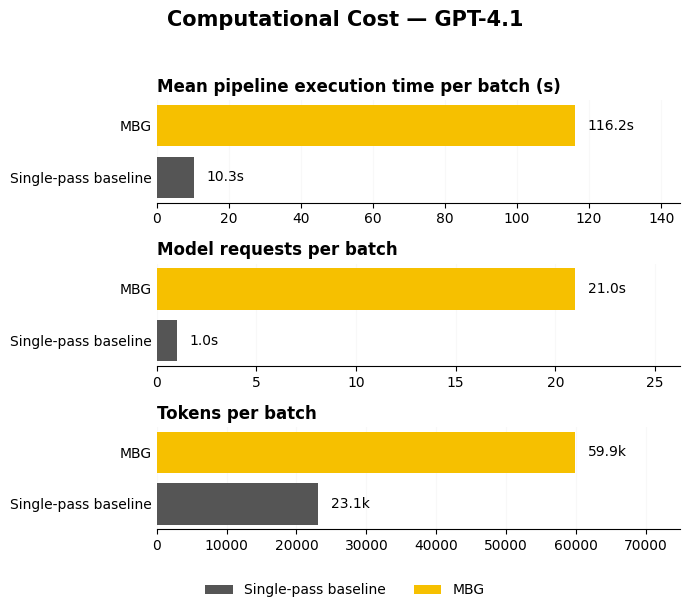

In [67]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Poster color palette
# -----------------------------
BASELINE = "#555555"
MBG = "#F6C000"
GRID = "#DDDDDD"

# -----------------------------
# Data: GPT-4.1, single-pass baseline vs MBG
# Runtime = mean pipeline execution time per batch/run
# -----------------------------
runtime = {
    "Single-pass baseline": 10.32,
    "MBG": 116.19
}

requests = {
    "Single-pass baseline": 1,
    "MBG": 21
}

tokens = {
    "Single-pass baseline": 23148,
    "MBG": 59896
}

# -----------------------------
# Create figure
# -----------------------------
fig, axes = plt.subplots(3, 1, figsize=(7, 6))

metrics = [
    ("Mean pipeline execution time per batch (s)", runtime),
    ("Model requests per batch", requests),
    ("Tokens per batch", tokens),
]

for ax, (title, data) in zip(axes, metrics):

    labels = list(data.keys())
    values = list(data.values())

    bars = ax.barh(
        labels,
        values,
        color=[BASELINE, MBG]
    )

    ax.set_title(title, loc="left", fontsize=12, weight="bold")

    for bar, value in zip(bars, values):

        if "Tokens" in title:
            label = f"{value/1000:.1f}k"
        elif "Requests" in title:
            label = f"{value:.0f}"
        else:
            label = f"{value:.1f}s"

        ax.text(
            bar.get_width() + max(values) * 0.03,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=10
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.grid(axis="x", alpha=0.18, color=GRID)
    ax.set_axisbelow(True)

    ax.tick_params(axis="y", length=0)

    # Give labels room on the right
    ax.set_xlim(0, max(values) * 1.25)

# Overall title
fig.suptitle(
    "Computational Cost — GPT-4.1",
    fontsize=15,
    weight="bold"
)

# One shared legend at the bottom
legend_elements = [
    Patch(facecolor=BASELINE, label="Single-pass baseline"),
    Patch(facecolor=MBG, label="MBG"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.savefig("cost_gpt_absolute.svg", bbox_inches="tight")
plt.savefig("cost_gpt_absolute.png", dpi=300, bbox_inches="tight")
plt.show()